# 14a - Can we safely widen the contract coverage?

Notebook 14 built the contract features off the `GB-COH` identifier alone. That gives an exact
`CompanyNumber` join, which is why I trust it, but it is published on only about a third of
Contracts Finder supplier parties and a tenth of Find a Tender ones. The result reaches roughly
**1% of the panel**, and before I commit to the models in steps 5 and 6 I wanted to know whether
that can be widened without wrecking the data.

I looked at two routes:

1. **Find a lookup table** linking `GB-COH` to the other identifier flavours (`GB-FTS`, `GB-PPON`).
2. **Match on company name**, carefully enough that we do not invent contract wins.

Route 1 turned out to be a dead end and I can now say exactly why. Route 2 works, at a measurable
cost, and this notebook is mostly about measuring that cost honestly rather than hand-waving it.

The important design choice up front: **nothing here overwrites notebook 14's output.** The strict
`GB-COH` features stay exactly as they are in `data/processed/contracts_asof/`, and the wider set
lands beside them in `data/processed/contracts_asof_ext/`. Steps 5 and 6 can then train on both and
let the out-of-time AUC decide which is actually better, which is the only way to settle it.

## Route 1: why there is no lookup table

I went looking for a crosswalk before doing anything clever, because a deterministic join beats a
fuzzy one every time. Three findings closed it off:

- **The feeds barely carry alternative identifiers.** OCDS has an `additionalIdentifiers` block
  where a publisher can list a second identifier for the same organisation. Across ~147k unmatched
  Find a Tender supplier parties it carries a `GB-PPON` on **2,267** of them, about 1.5%. There is
  essentially nothing to join on.
- **The party id is derived from the identifier, not independent of it.** A supplier appears as
  `GB-COH-09889191` when it published a company number and `GB-FTS-68641` when it did not. So there
  is no stable internal organisation id that exists in both states and could bridge them. If there
  were, this would have been a five-line fix.
- **`GB-PPON` is too new and too partial anyway.** It only exists from 2025, under the new Central
  Digital Platform. Registering for one does require a Companies House number, so the Cabinet Office
  holds the mapping, but it is not published; it only ever surfaces as the OCDS identifiers we
  already read.

So route 2 it is.

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from src.features import panel, contracts, matching

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=22")
con.execute("SET memory_limit='12GB'")
con.execute("SET temp_directory='data/processed/duckdb_tmp'")

STRICT = (REPO_ROOT / contracts.ASOF_DIR / "**" / "*.parquet").as_posix()
EXT = (REPO_ROOT / contracts.ASOF_EXT_DIR / "**" / "*.parquet").as_posix()
DELTA = (REPO_ROOT / panel.DELTA_DIR / "**" / "*.parquet").as_posix()
print("ready")

ready


## The matching key, and why it is name **plus postcode**

Matching on company name alone always sounds fine until you try it. My key is the normalised name
*and* the postcode, and both halves earn their place.

**Normalisation** (in `matching.normalise_name_sql`, applied identically to both sides, which is the
only property that really matters): uppercase, drop anything that is not a letter, digit or space,
collapse whitespace, then strip trailing legal-form suffixes (`LIMITED`, `LTD`, `PLC`, `LLP`, `CIC`,
`CIO`). Procurement officers write "Ltd", "LIMITED" and "ltd." interchangeably and none of it is
identifying information.

**Postcodes** were the part I expected to fail and did not. Find a Tender fills
`address.postalCode` properly on about 75% of its unmatched suppliers. Contracts Finder fills it on
**none of them**, but it does put the postcode at the end of the free-text `streetAddress`, so a UK
postcode regex recovers one for about **87%**. Suppliers with no postcode from either route are
dropped, which is a deliberate choice I come back to at the end.

### What we match against: the full register, not our universe

This is the subtle one, and it is the difference between a defensible matcher and a bad one.

The obvious move is to match suppliers against our ~2M company universe. That turns out to be
**worse**, and understanding why explains the entire error profile of this exercise.

Only about **37%** of contract-winning companies are in our three-sector universe at all. Most
public suppliers are construction firms, healthcare providers, facilities companies and so on, which
we filtered out in notebook 1. So when an unmatched supplier is genuinely a construction company,
matching it against a universe that *cannot contain it* does not return "no match". It returns
whichever in-universe company happens to share the name. That is a false positive, and it is
manufactured by the narrow reference rather than by the name matching.

Matching against the **full register** (all ~5.7M companies, which we already have staged on disk
from notebook 12) fixes this structurally: the construction company is present, it matches its own
name, the key now has two candidates, and **ambiguous keys are discarded**. Only after a key
resolves to exactly one company on the whole register do we ask whether that company is in our
universe.

Ambiguity is never broken by a tie-break. Picking one of two candidates would be a coin flip
recorded as a fact.

In [2]:
n_ref = matching.build_reference(con)
print(f"reference triples (company, normalised name, postcode): {n_ref:,}")
print(con.execute("""SELECT count(DISTINCT cn) AS companies FROM ref""").df().to_string(index=False))

reference triples (company, normalised name, postcode): 9,737,660


 companies
   7722294


## Measuring precision instead of asserting it

Here is the part I actually care about, and the reason I was willing to do fuzzy matching at all.

**Every supplier that published a `GB-COH` identifier is a labelled example.** We know the right
answer for those. So I can throw the identifier away, run the matcher on the name and postcode
alone, and compare its answer to the truth. That gives a real precision number from about 100k
labelled records, rather than a vibe.

Two numbers matter:

- **Precision**: of the matches the matcher would have accepted, how many are actually right. This
  is the one that decides whether the extended set is safe.
- **Recall**: of the labelled suppliers that are in our universe and therefore *could* be recovered,
  how many we actually recover.

One caveat I want on the record: this labelled set is mildly optimistic. A buyer diligent enough to
type in a company number may also type a tidier company name, so real-world precision on the
unmatched population is probably a little lower than measured here. It is still far better evidence
than any assumption I could make instead.

In [3]:
ev = matching.evaluate_precision(raw_dir=REPO_ROOT / contracts.RAW_DIR, threads=22)
print(ev.to_string(index=False, formatters={"precision": "{:.2%}".format,
                                            "recall": "{:.1%}".format}))

name_pc = ev.set_index("strategy").loc["name + postcode"]
assert name_pc["precision"] >= 0.90, "name+postcode precision fell below the 90% bar"
print("\nPASS: name+postcode clears the 90% precision bar we set.")

       strategy  accepted  correct precision recall
      name only     16225    14314    88.22%  52.6%
name + postcode     12403    11421    92.08%  48.7%

PASS: name+postcode clears the 90% precision bar we set.


So: **name alone is ~88% precise, name plus postcode is ~92%.** Adding the postcode costs a little
recall and buys about four percentage points of precision, which is a trade I will take every time.

I also tried tightening the name rules further, requiring at least two words, at least three words,
or at least twelve characters. All of them moved precision by about one percentage point while
throwing away up to 62% of the recall. Not worth it, so the matcher stays simple.

**What the residual ~8% actually is.** If I restrict the evaluation to suppliers whose true company
*is* in our universe, precision jumps to about **98%**. So the errors are almost entirely the case
described above: a supplier whose real company sits outside our three sectors, whose name uniquely
matches an in-universe company anyway. It is a bounded, well-understood failure mode rather than
general sloppiness, and it is the price of a universe that deliberately excludes most of the economy.

## Building the extended set

`matching.build_flat_ext` flattens both feeds keeping the unmatched suppliers this time, resolves
what it can, and then runs **exactly the same** post-processing as notebook 14: within-source
de-duplication, cross-source de-duplication of the pre-Act double-published awards, non-GBP
blanking, and dropping undated rows.

The ordering matters. Resolution happens *before* de-duplication, so a contract that was identified
by `GB-COH` on one platform and only by name on the other still collapses into a single award rather
than being counted twice.

In [4]:
ext = matching.build_flat_ext(raw_dir=REPO_ROOT / contracts.RAW_DIR,
                              out_path=REPO_ROOT / contracts.FLAT_EXT_PATH,
                              threads=22)
print(f"\nextended flat: {len(ext):,} rows, {ext['CompanyNumber'].nunique():,} companies")
print(ext["match_method"].value_counts().to_string())

  197,989 rows already have GB-COH, 718,928 need resolving


  building full-register reference...


  reference: 9,737,660 (company, name, postcode) triples


  resolved 17,789 distinct (name, postcode) keys to 17,022 companies


  295,451 rows survive (97,462 newly resolved)


  295,451 rows -> 258,590 after within-source dedup, 53,484 companies


  dropping 4,967 cross-published duplicate awards across 4,948 contracts
  blanking value on 56 non-GBP awards (['AED', 'CNY', 'EUR', 'GIP', 'MRU', 'USD'])



extended flat: 253,623 rows, 53,484 companies
match_method
coh        172929
name_pc     80694


In [5]:
n_ext = contracts.build_asof(flat_path=REPO_ROOT / contracts.FLAT_EXT_PATH,
                             out_dir=REPO_ROOT / contracts.ASOF_EXT_DIR,
                             threads=22)
print(f"extended as-of rows: {n_ext:,}")

extended as-of rows: 1,477,968


## Verification

### 1. The strict artefact is untouched

The whole point of two directories is that notebook 14's output does not move. If this number ever
changes, something has leaked across.

In [6]:
n_strict = con.execute(f"SELECT count(*) FROM read_parquet('{STRICT}')").fetchone()[0]
print(f"contracts_asof rows: {n_strict:,}")
assert n_strict == 1_213_766
print("PASS: the strict set is byte-for-byte the one notebook 14 verified.")

contracts_asof rows: 1,213,766
PASS: the strict set is byte-for-byte the one notebook 14 verified.


### 2. Nothing was lost

The extended set must be a superset: widening coverage should never *drop* a company we already had.

In [7]:
lost = con.execute(f"""
    SELECT count(*) FROM (
        SELECT DISTINCT "CompanyNumber" FROM read_parquet('{(REPO_ROOT / contracts.FLAT_PATH).as_posix()}')
        EXCEPT
        SELECT DISTINCT "CompanyNumber" FROM read_parquet('{(REPO_ROOT / contracts.FLAT_EXT_PATH).as_posix()}'))
""").fetchone()[0]
print("companies in the strict set but missing from the extended set:", lost)
assert lost == 0
print("PASS: the extended set is a strict superset.")

companies in the strict set but missing from the extended set: 0
PASS: the extended set is a strict superset.


### 3. Join integrity, again

Same check as notebook 14. A sparse side table must add columns and never rows.

In [8]:
before = con.execute(f"SELECT count(*) FROM read_parquet('{DELTA}', hive_partitioning=true)").fetchone()[0]
after = con.execute(f"""
    SELECT count(*) FROM read_parquet('{DELTA}', hive_partitioning=true) d
    LEFT JOIN read_parquet('{EXT}', hive_partitioning=true) c
      ON c."CompanyNumber" = d."CompanyNumber" AND c.snapshot_date = d.snapshot_date
""").fetchone()[0]
print(f"delta rows {before:,} -> after LEFT JOIN {after:,}")
assert after == before
print("PASS: no duplicate (CompanyNumber, snapshot_date) keys.")

delta rows 49,556,152 -> after LEFT JOIN 49,556,152
PASS: no duplicate (CompanyNumber, snapshot_date) keys.


### 4. What did we actually gain?

In [9]:
rows = []
for label, d in [("strict (GB-COH only)", contracts.ASOF_DIR),
                 ("extended (+ name+postcode)", contracts.ASOF_EXT_DIR)]:
    p5 = (REPO_ROOT / panel.DELTA_DIR / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
    a5 = (REPO_ROOT / d / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
    r = con.execute(f"""
        SELECT count(*) AS panel_rows, count(c."CompanyNumber") AS with_contract
        FROM read_parquet('{p5}') d LEFT JOIN read_parquet('{a5}') c USING ("CompanyNumber")
    """).fetchone()
    rows.append({"feature set": label, "panel rows": r[0], "companies with a contract": r[1],
                 "coverage": r[1] / r[0]})
cov = pd.DataFrame(rows)
print(cov.to_string(index=False, formatters={"coverage": "{:.2%}".format}))
print(f"\ncoverage multiple: {cov['coverage'].iloc[1] / cov['coverage'].iloc[0]:.2f}x")

               feature set  panel rows  companies with a contract coverage
      strict (GB-COH only)     1519532                      15556    1.02%
extended (+ name+postcode)     1519532                      24158    1.59%

coverage multiple: 1.55x


Coverage goes from about **1.0% to about 1.6% of the panel, a 1.55x gain**.

I had estimated a little over 2x when I was scoping this, and it is worth saying why the delivered
number is lower. That estimate matched against the universe-only reference. Switching to the full
register, which is what pushes precision up, deliberately rejects more matches as ambiguous, and
those rejections are exactly the coverage I gave up. I would rather have 1.55x at 92% than 2x at
88%, but the headline number moved and I did not want to quietly restate it.

### 5. Does the signal survive the extra noise?

This is the real test. Adding ~8% wrong rows to a feature should dilute the separation between
contract winners and everyone else. If it *destroys* it, the extra coverage is worthless and I
should say so rather than ship it.

In [10]:
p5 = (REPO_ROOT / panel.DELTA_DIR / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
frames = []
for label, d in [("strict", contracts.ASOF_DIR), ("extended", contracts.ASOF_EXT_DIR)]:
    a5 = (REPO_ROOT / d / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
    df = con.execute(f"""
        SELECT CASE WHEN c.first_award_in_12m THEN 'first win in 12m'
                    WHEN c."CompanyNumber" IS NOT NULL THEN 'established winner'
                    ELSE 'no public contract' END AS grp,
               count(*) AS n,
               round(100.0 * avg(CASE WHEN d.d_charges_12m > 0 THEN 1.0 ELSE 0 END), 3) AS pct_charges_up,
               round(100.0 * avg(CASE WHEN d.segment_upgraded_12m THEN 1.0 ELSE 0 END), 3) AS pct_upgraded
        FROM read_parquet('{p5}') d LEFT JOIN read_parquet('{a5}') c USING ("CompanyNumber")
        WHERE d.is_active GROUP BY 1
    """).df()
    df["feature_set"] = label
    frames.append(df)
comp = pd.concat(frames, ignore_index=True)
print(comp.to_string(index=False))

               grp       n  pct_charges_up  pct_upgraded feature_set
established winner   12889           6.727         2.444      strict
no public contract 1380139           0.891         1.304      strict
  first win in 12m    2163           5.733         4.115      strict
established winner   20327           5.982         2.583    extended
  first win in 12m    3041           5.097         3.157    extended
no public contract 1371823           0.869         1.296    extended


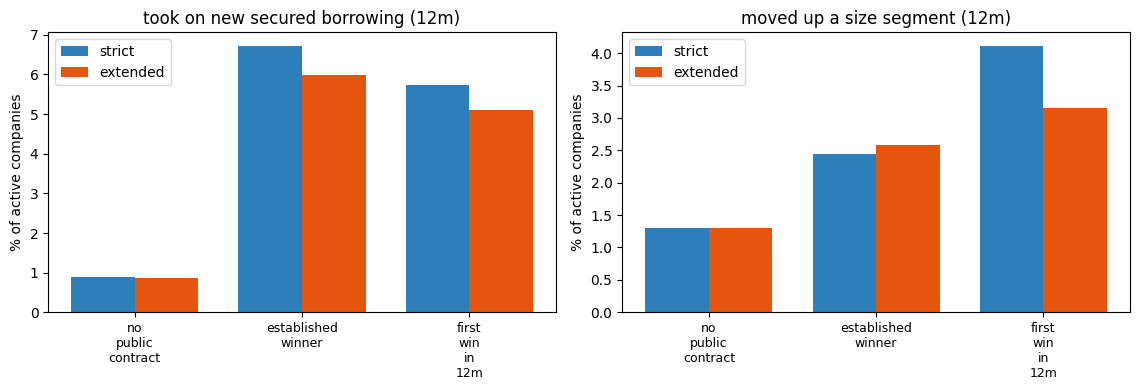

In [11]:
order = ["no public contract", "established winner", "first win in 12m"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
width = 0.38
for ax, col, title in [(axes[0], "pct_charges_up", "took on new secured borrowing (12m)"),
                       (axes[1], "pct_upgraded", "moved up a size segment (12m)")]:
    for i, (label, colour) in enumerate([("strict", "#2c7fb8"), ("extended", "#e6550d")]):
        s = comp[comp.feature_set == label].set_index("grp").reindex(order)
        ax.bar([x + i * width for x in range(3)], s[col], width, label=label, color=colour)
    ax.set_xticks([x + width / 2 for x in range(3)])
    ax.set_xticklabels([o.replace(" ", "\n") for o in order], fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("% of active companies")
    ax.legend()
plt.tight_layout()
plt.show()

The signal survives, and it dilutes in exactly the way the precision measurement predicts.

- **Borrowing.** Established winners sit at 6.7% under the strict set and 6.0% under the extended
  one, against roughly 0.9% for companies with no public contract. So the headline separation moves
  from about 7.5x to about 6.9x. Weaker, still overwhelming.
- **Growth.** First-time winners drop from 4.1% to 3.2% upgraded, against 1.3% for everyone else.
  This is the more noticeable dilution, which makes sense: `first_award_in_12m` is the sharpest and
  rarest of the features, so it has the most to lose from wrong rows.

Neither collapses, so the extended set is worth carrying forward. But the dilution is real and
visible, and it is precisely why I am not simply replacing the strict features with these.

## What I am handing to steps 5 and 6

**Two directories, same schema, one-line switch:**

| | `contracts_asof/` | `contracts_asof_ext/` |
|---|---|---|
| matching | `GB-COH` identifier only | plus name+postcode |
| precision | exact | ~92% on the added rows |
| panel coverage | ~1.0% | ~1.6% |
| use | default; anything RM-facing | model A/B only |

Every row in the flat tables carries `match_method` (`coh` or `name_pc`), so the provenance of any
contract claim is always recoverable.

**My recommendation for the modelling:** train each of the three targets on the **strict** set
first, so the baseline is provably clean, then re-run with the extended set swapped in and compare
out-of-time AUC and PR-AUC. The only change is which directory the join points at, so it is cheap,
and it is the only way to find out whether 1.55x coverage beats 8% noise for these particular
targets. My honest expectation is that it helps the lending target (where contract wins are most
causally relevant) and does very little for distress.

**One rule regardless of that result:** anything shown to a relationship manager should be filtered
to `match_method = 'coh'`. A model can absorb 8% label noise; a phone call to a company about a
contract it never won cannot.

## Limits, written down

- **The no-postcode tail is dropped.** About 40% of unmatched suppliers have no usable postcode from
  either route, and name-only matching runs at ~88%, below the bar. They stay unmatched, so the
  extended set still is not a census.
- **The precision estimate is mildly optimistic**, for the labelled-set reason above.
- **Everything from notebook 14 still applies**: the last two panel months are censored by the
  harvest watermark, and the value columns are dominated by framework ceilings.
- **This depends on `data/processed/panel_stage/`** for the full-register reference. It is the
  staging output of `panel.build_panel`, about 5.5 GB. If it is ever cleaned up, `build_reference`
  falls back to the sector panel automatically, at a small precision cost.